In [9]:
import os as os
import sys
import numpy as np

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)
import matplotlib.pyplot as plt
from scripts.wosa import wosa
from scripts.lpsd import lpsd
from scripts.logpsd import logpsd
from scripts.readTdi import readTdi, getTdiPath

In [14]:
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data, fs, t = readTdi(tdi_path)

f_logpsd, psd_logpsd, _ = logpsd(x=data, fs=fs, overlap=0, L1=100000)

['L_1', 'L_1', '(0.6)^1 L_1', '(0.6)^2 L_1', '(0.6)^3 L_1', '(0.6)^4 L_1', '(0.6)^5 L_1', '(0.6)^6 L_1', '(0.6)^7 L_1', '(0.6)^8 L_1', '(0.6)^9 L_1', '(0.6)^10 L_1', '(0.6)^11 L_1', '(0.6)^12 L_1', '(0.6)^13 L_1', '(0.6)^14 L_1', '(0.6)^15 L_1', '(0.6)^16 L_1', '(0.6)^17 L_1', '(0.6)^18 L_1', '(0.6)^19 L_1']
Lk_list: [100000, 100000, 60000, 36000, 21599, 12960, 7775, 4665, 2799, 1679, 1007, 604, 362, 217, 130, 78, 47, 28, 16, 10]
fk_list: [8e-06, 8e-06, 1.3333333333333333e-05, 2.2222222222222223e-05, 3.703875179406454e-05, 6.17283950617284e-05, 0.00010289389067524115, 0.00017148981779206859, 0.000285816362986781, 0.00047647409172126264, 0.0007944389275074479, 0.0013245033112582781, 0.0022099447513812156, 0.003686635944700461, 0.006153846153846154, 0.010256410256410256, 0.01702127659574468, 0.02857142857142857, 0.05, 0.08]


In [11]:
f_wosa, psd_wosa, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=5000
) 

In [12]:
f_lpsd, psd_lpsd = lpsd(
    x=data,
    fs=fs
) 

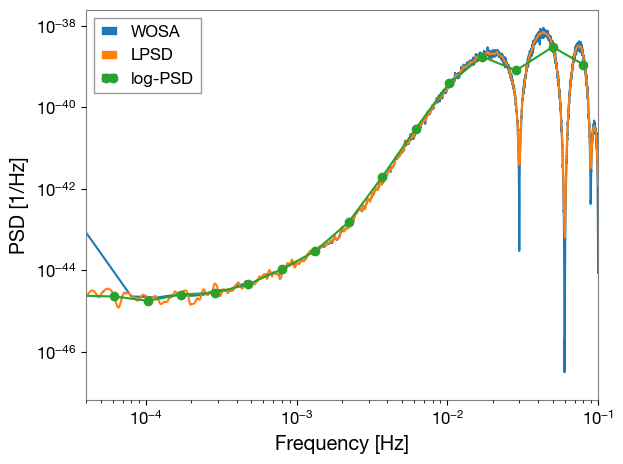

In [25]:
# example Nyquist frequency – use whatever is correct for your data
f_nyq = fs/2          # or fs/2 if you still have the sample-rate variable

fig, ax = plt.subplots()

ax.plot(f_wosa,  psd_wosa,       label='WOSA')                 # 10 001 points
ax.plot(f_lpsd,  psd_lpsd,       label='LPSD')                 # e.g. 300 points
ax.plot(f_logpsd, psd_logpsd, 'o-', label='log-PSD')           # 24 points → show markers

#––– cosmetics ––––––––––––––––––––––––––––––––––––––––––––––––
ax.set_xlim(fs/5000, f_nyq)               # 0 → Nyquist on the x-axis
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('PSD [1/Hz]')

# PSDs usually span many orders of magnitude,
# so a log scale is often clearer (optional):
ax.set_xscale('log')
ax.set_yscale('log')

ax.grid(True, which='both', ls=':', lw=0.5)
ax.legend()
fig.tight_layout()
ax.grid(False, which='both')
plt.show()
